# Importing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import optuna
import warnings
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split, ShuffleSplit, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, recall_score, precision_score, classification_report

In [2]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

# Reading The Data

In [3]:
data = pd.read_csv("../data/train.csv")

## Show The 5 First Rows

In [4]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Show The 5 Last Rows

In [5]:
data.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


# EDA

In [6]:
data.shape # (rows_count, columns_count)

(891, 12)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
data.drop(columns=["PassengerId", "Survived"]).describe()

,Pclass,Age,SibSp,Parch,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,2.000000,20.125000,0.000000,0.000000,7.910400
50%,3.000000,28.000000,0.000000,0.000000,14.454200
75%,3.000000,38.000000,1.000000,0.000000,31.000000
max,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
print("Total Of Null Values ", data.isna().sum().sum())
data.isna().sum()

Total Of Null Values  866


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
data.duplicated().sum()

np.int64(0)

In [11]:
# Now we can delete the PassengerID becuase it's just a personal information same as name
data["PassengerId"].unique().shape

(891,)

In [12]:
print("Survived", np.unique(data["Survived"], return_counts=True) , "\nGender", np.unique(data["Sex"], return_counts=True))

Survived (array([0, 1]), array([549, 342])) 
Gender (array(['female', 'male'], dtype=object), array([314, 577]))


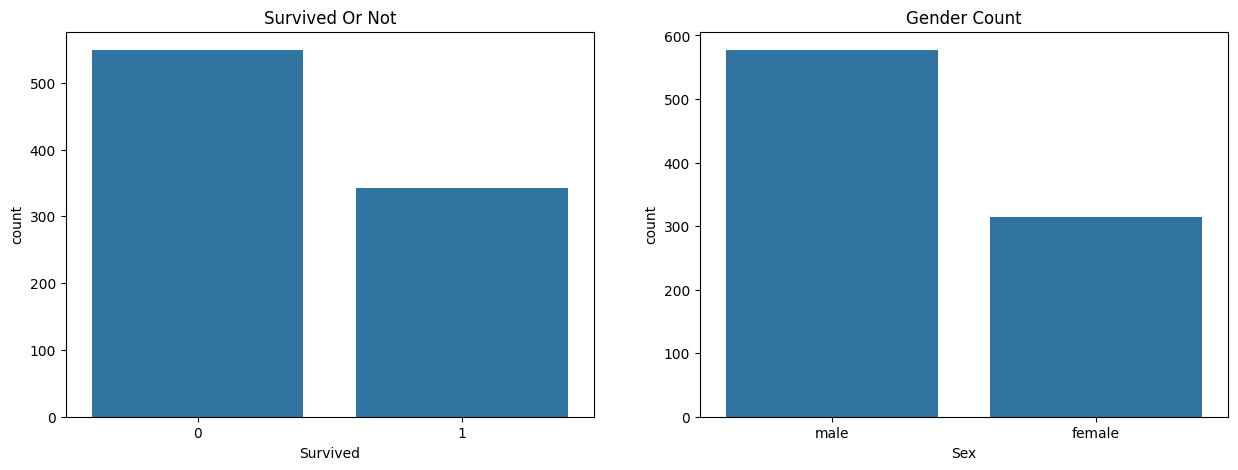

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(15,5))

sns.barplot(data["Survived"].value_counts(), ax=axes[0])
axes[0].set_title("Survived Or Not")

sns.barplot(data["Sex"].value_counts(), ax=axes[1])
axes[1].set_title("Gender Count")

plt.show()

# The dataset contains more non-survivors than survivors, indicating a moderate class imbalance. 
#     Additionally, male passengers make up a larger proportion of the dataset than female passengers. 
#     These distributions provide useful context for the analyses that follow.

In [ ]:
# Calculate the average survival rate for each gender and visualize the results using a bar chart.

gender_grp_survival_rate = data.groupby("Sex")["Survived"].mean()

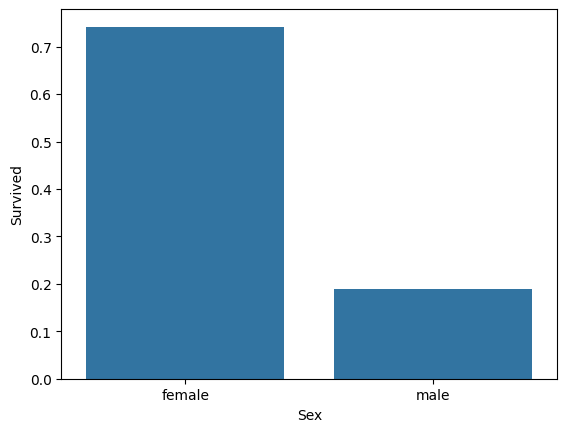

In [ ]:
sns.barplot(gender_grp_survival_rate)
plt.show()

### Observation

# A clear difference is observed between the two groups. Female passengers had a survival rate of approximately 74%, while only about 19% of male passengers survived.
# This suggests that gender was one of the strongest factors associated with survival in the Titanic dataset.

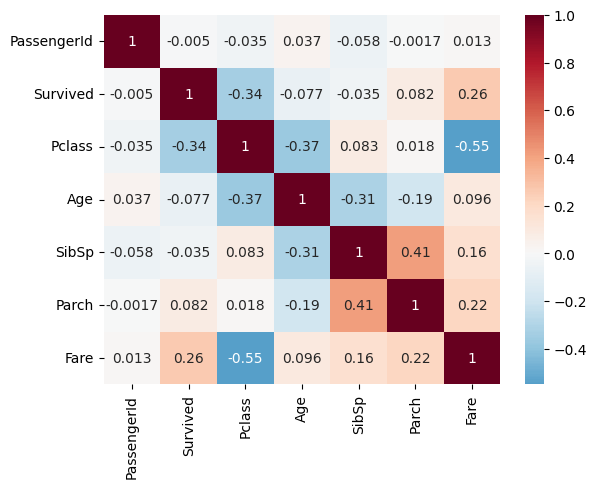

In [ ]:
# Visualize the relationships between numerical features and identify variables that are potentially associated with passenger survival.

sns.heatmap(data.corr(numeric_only=True), center=0, annot=True, cmap="RdBu_r")
plt.show()

# Pclass shows the strongest correlation with Survived (-0.34), indicating that first-class passengers had higher survival rates.
# Fare is positively correlated with Survived (0.26), suggesting that passengers paying higher fares were more likely to survive.
# Fare and Pclass are strongly negatively correlated (-0.55), as higher-class passengers generally paid more.
# Age has a weak relationship with survival, implying limited predictive power on its own.
# PassengerId exhibits negligible correlations and is unlikely to provide useful information for modeling

In [ ]:
# Calculate the average survival rate for each SibSp and Parch.

sibsp_grp = data.groupby("SibSp")["Survived"].mean()
parch_grp = data.groupby("Parch")["Survived"].mean()

Suvival Rate For Each Parch
Parch
0    0.343658
1    0.550847
2    0.500000
3    0.600000
4    0.000000
5    0.200000
6    0.000000
Name: Survived, dtype: float64


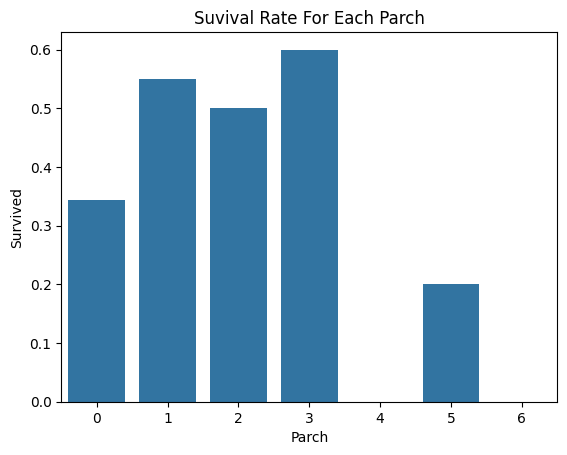

In [ ]:
# Visualize the survival rate for each Parch category.

print("Suvival Rate For Each Parch")
print(parch_grp)


sns.barplot(parch_grp)
plt.title("Suvival Rate For Each Parch")
plt.show()

# Insights:
# - Passengers traveling alone (Parch = 0) had a noticeably lower survival rate.
# - Those traveling with one or two parents/children generally showed higher survival rates.
# - Although passengers with three accompanying family members appear to have an even higher survival rate,
#   this group contains only a small number of observations.
# - Therefore, we cannot confidently conclude that traveling with three family members
#   increased the probability of survival, as the sample size is too limited.

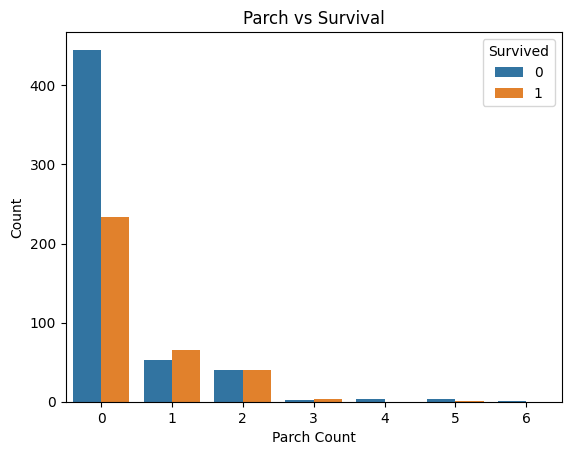

In [ ]:
# Display the distribution of passengers for each Parch category,
# separated by survival status.
# This visualization helps verify whether the survival rates observed
# in the previous bar plot are supported by the underlying sample sizes.

sns.countplot(
    data=data,
    x='Parch',
    hue='Survived'
)

plt.title('Parch vs Survival')
plt.xlabel('Parch Count')
plt.ylabel('Count')
plt.show()

# Insights:
# - Most passengers traveled without parents or children (Parch = 0),
#   making it the largest group in the dataset.
# - Categories with higher survival rates in the previous chart generally
#   contain fewer passengers, so their survival percentages should be
#   interpreted with caution.
# - This count plot provides important context by revealing the sample size
#   behind each category, allowing us to distinguish genuine patterns from
#   potentially misleading results caused by small groups.

Suvival Rate For Each SibSp
SibSp
0    0.345395
1    0.535885
2    0.464286
3    0.250000
4    0.166667
5    0.000000
8    0.000000
Name: Survived, dtype: float64


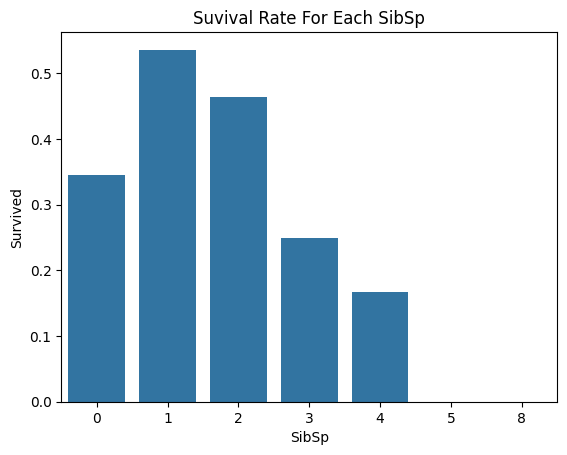

In [ ]:
# Visualize the survival rate for each SibSp category.

print("Suvival Rate For Each SibSp")
print(sibsp_grp)


sns.barplot(sibsp_grp)
plt.title("Suvival Rate For Each SibSp")
plt.show()

# Insights:
# - Passengers traveling alone (SibSp = 0) had the lowest survival rate,
#   which is consistent with the pattern observed for the Parch feature.
# - Passengers traveling with one companion generally had a higher chance of survival.
# - This suggests that having close family members aboard—whether a spouse,
#   sibling, parent, or child—may have been associated with a higher survival rate.
# - However, categories with two or more companions contain relatively few passengers,
#   making their survival rates less reliable.
# - Therefore, conclusions drawn from these smaller groups should be interpreted
#   with caution due to the limited sample size.

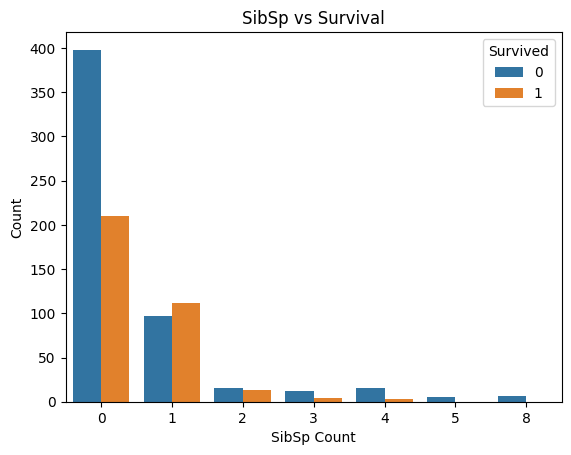

In [ ]:
# Display the distribution of passengers for each SibSp category,
# separated by survival status.
# This plot helps validate whether the survival rates observed in the
# previous bar chart are supported by sufficient sample sizes.

sns.countplot(
    data=data,
    x='SibSp',
    hue='Survived'
)

plt.title('SibSp vs Survival')
plt.xlabel('SibSp Count')
plt.ylabel('Count')
plt.show()

# Insights:
# - Most passengers traveled without siblings or spouses (SibSp = 0),
#   making it the largest group in the dataset.
# - The survival advantage observed for passengers with one companion
#   appears more reliable because this category contains a relatively
#   large number of observations.
# - In contrast, categories with two or more companions have much smaller
#   sizes, making their survival rates more susceptible to random variation.
# - Therefore, any apparent trends in these smaller groups should be
#   interpreted with caution.

In [ ]:
# Investigate the interaction between Parch and age group.
# Passengers are divided into children (Age < 18) and adults,
# then grouped by their Parch value.
#
# For each subgroup, we compute:
# - mean: survival rate
# - count: number of observations
#
# This allows us to examine whether traveling with parents or children
# affects survival differently for children and adults.

parch_age_survival_rate = data.groupby(
    ['Parch', data['Age'] < 18]
)['Survived'].agg(["mean", "count"])

In [ ]:
# Convert the grouped DataFrame into separate lists for visualization.
#
# We extract:
# - the group labels (Parch, IsChild)
# - the corresponding survival rates
# - the number of observations in each group
#
# These lists will be used in the following visualizations.

parch_age_info = []
parch_age_mean_values = []
parch_age_count_values = []

# Display floating-point numbers in standard decimal notation
# instead of scientific notation.
np.set_printoptions(suppress=True)


for idx, info in enumerate(parch_age_survival_rate.index):
    parch_age_info.append(f"{info}")
    parch_age_mean_values.append(parch_age_survival_rate.values[idx][0])
    parch_age_count_values.append(parch_age_survival_rate.values[idx][1])

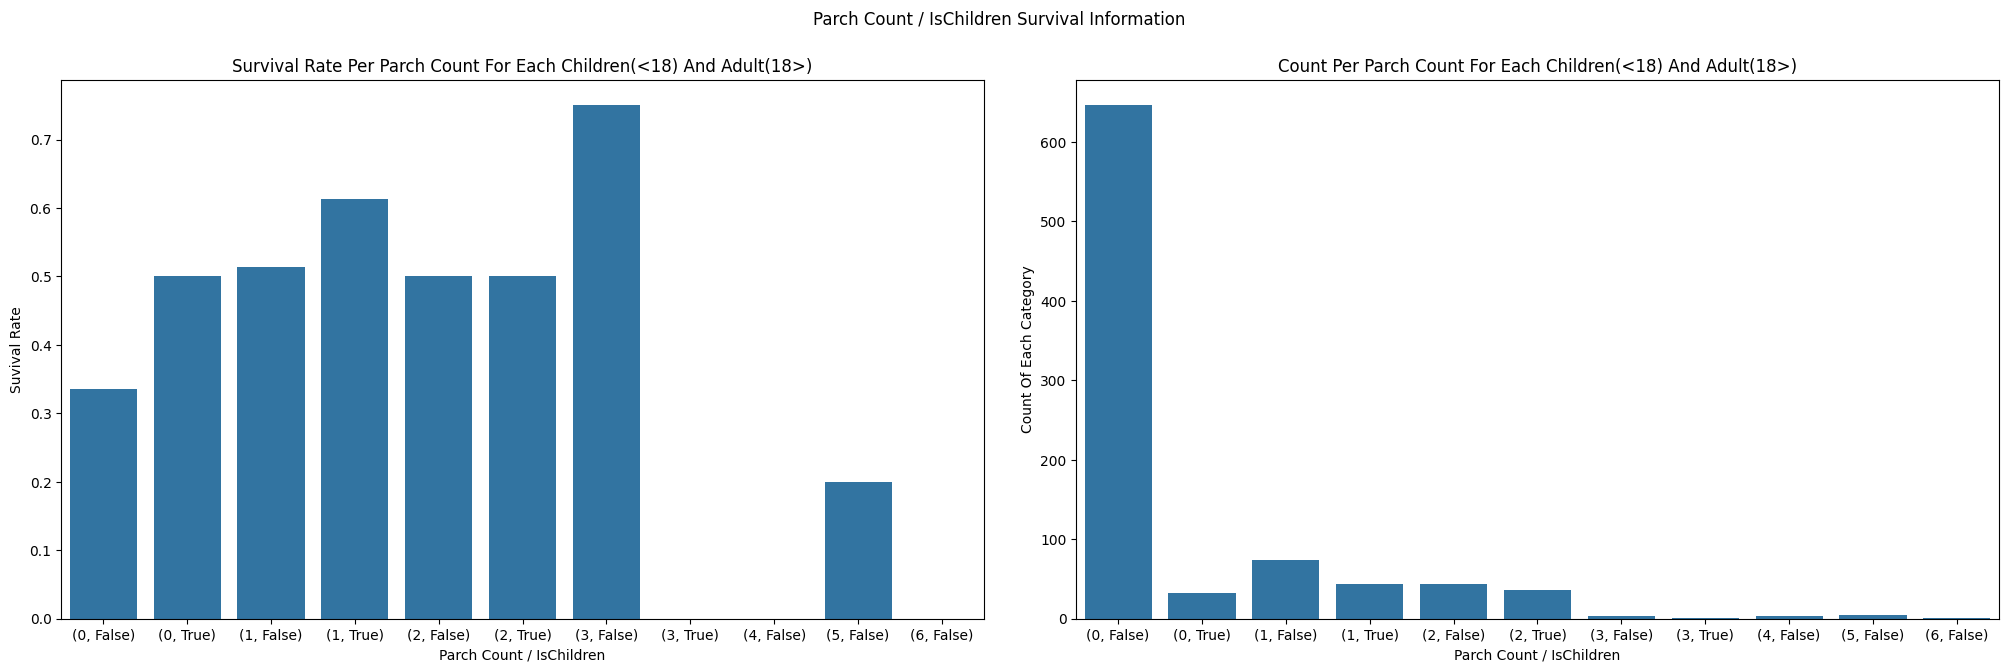

In [ ]:
# Compare survival rates and sample sizes across Parch categories,
# separately for children (Age < 18) and adults.

fig, axes = plt.subplots(1,2, figsize=(25,7))

sns.barplot(x=parch_age_info, y=parch_age_mean_values, ax=axes[0])
axes[0].set_xlabel("Parch Count / IsChildren")
axes[0].set_ylabel("Suvival Rate")
axes[0].set_title("Survival Rate Per Parch Count For Each Children(<18) And Adult(18>)")

sns.barplot(x=parch_age_info, y=parch_age_count_values, ax=axes[1])
axes[1].set_xlabel("Parch Count / IsChildren")
axes[1].set_ylabel("Count Of Each Category")
axes[1].set_title("Count Per Parch Count For Each Children(<18) And Adult(18>)")

plt.suptitle("Parch Count / IsChildren Survival Information")
plt.subplots_adjust(wspace=0.1)
plt.tight_layout(rect=[0,0,0,0.99999], w_pad=0.1)
plt.show()

# Insights:
# - Children generally exhibit higher survival rates than adults across most Parch categories.
# - The dataset contains substantially more adults than children, resulting in
#   more reliable estimates for adult groups.
# - Among children, those traveling with one or two parents/children aboard
#   appear to have the highest survival rates.
# - However, categories with Parch values of three or greater contain very few
#   observations, so their survival rates should be interpreted with caution.

In [ ]:
# Group passengers by the number of parents/children aboard (Parch)
# and their sex.
# For each group, calculate:
# - the mean survival rate
# - the number of passengers
#
# This analysis allows us to compare how the relationship between
# Parch and survival differs for male and female passengers.

parch_sex_survival_rate = data.groupby(
    ["Parch", "Sex"]
)["Survived"].agg(["mean", "count"])

In [ ]:
parch_sex_info = []
parch_sex_mean_values = []
parch_sex_count_values = []

np.set_printoptions(suppress=True)
for idx, info  in enumerate(parch_sex_survival_rate.index):
    parch_sex_info.append(f"{info}")
    parch_sex_mean_values.append(parch_sex_survival_rate.values[idx][0])
    parch_sex_count_values.append(parch_sex_survival_rate.values[idx][1])

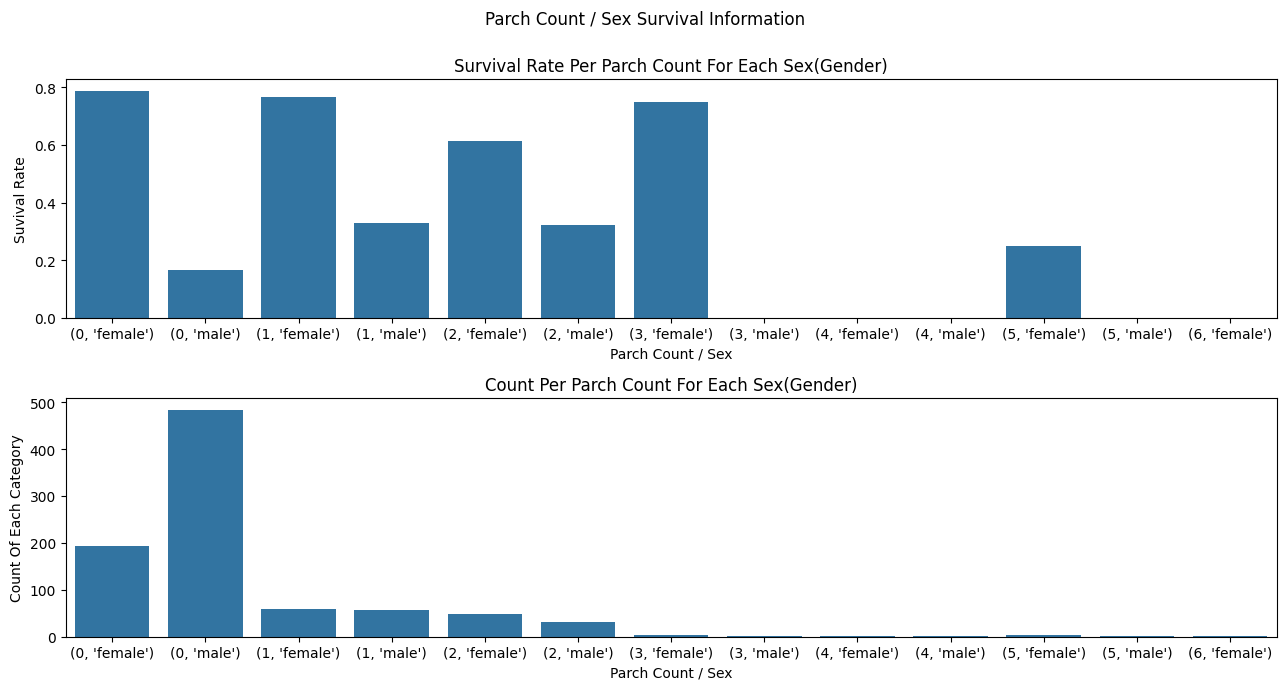

In [ ]:
# Compare survival rates and sample sizes across Parch categories,
# separately for male and female passengers.

fig, axes = plt.subplots(2,1, figsize=(13,7))

sns.barplot(x=parch_sex_info, y=parch_sex_mean_values, ax=axes[0])
axes[0].set_xlabel("Parch Count / Sex")
axes[0].set_ylabel("Suvival Rate")
axes[0].set_title("Survival Rate Per Parch Count For Each Sex(Gender)")

sns.barplot(x=parch_sex_info, y=parch_sex_count_values, ax=axes[1])
axes[1].set_xlabel("Parch Count / Sex")
axes[1].set_ylabel("Count Of Each Category")
axes[1].set_title("Count Per Parch Count For Each Sex(Gender)")

plt.suptitle("Parch Count / Sex Survival Information")
plt.subplots_adjust(hspace=0.1)
plt.tight_layout(
    rect=[0, 0, 1, 0.98])
plt.show()

# Insights:
# - Female passengers consistently exhibit higher survival rates than male passengers
#   across nearly all Parch categories.
# - This pattern is consistent with the historical evacuation policy of
#   "women and children first," which likely contributed to the higher
#   survival rates observed among female passengers.
# - The second chart shows the sample size for each subgroup, allowing us
#   to assess the reliability of the observed survival rates.

In [ ]:
# Calculate the survival rate for each passenger class (Pclass).
#
# Previous correlation analysis showed that Pclass is strongly associated
# with the target variable (Survived), with a negative correlation.
# This indicates that passengers in higher classes (lower Pclass values)
# generally had higher survival rates than those in lower classes

pclass_survival_rate = data.groupby("Pclass")["Survived"].mean()

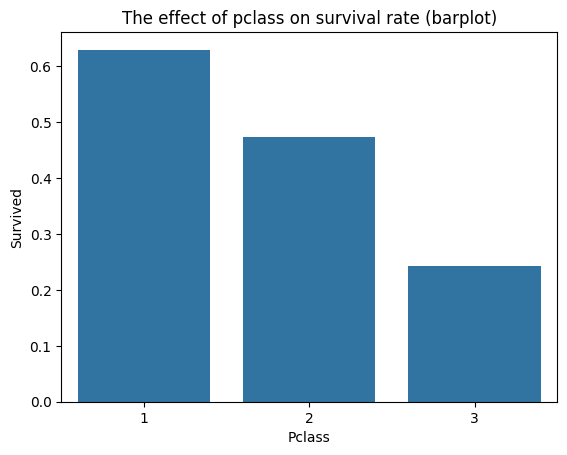

In [ ]:
# Visualize the survival rate for each passenger class (Pclass).
# The chart illustrates the relationship between passenger class
# and the probability of survival.

sns.barplot(pclass_survival_rate)
plt.title("The effect of pclass on survival rate (barplot)")
plt.show()

# Insights:
# - Survival rates decrease as the passenger class number increases.
# - First-class passengers exhibit the highest survival rate,
#   while third-class passengers have the lowest.
# - This pattern is consistent with the negative correlation observed
#   between Pclass and the target variable (Survived).

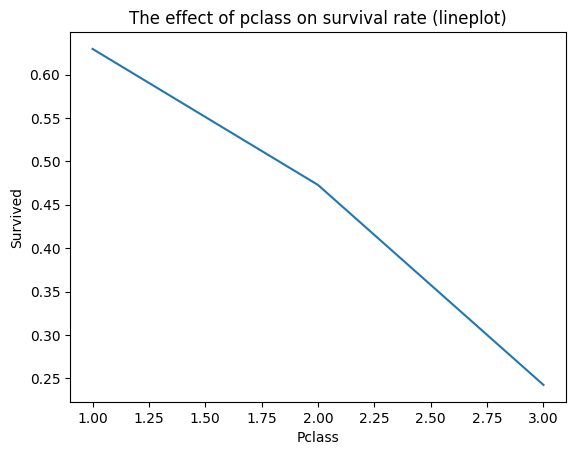

In [30]:
sns.lineplot(pclass_survival_rate)
plt.title("The effect of pclass on survival rate (lineplot)")
plt.show()

In [32]:
continuous_features = data[["Age", "Fare"]]

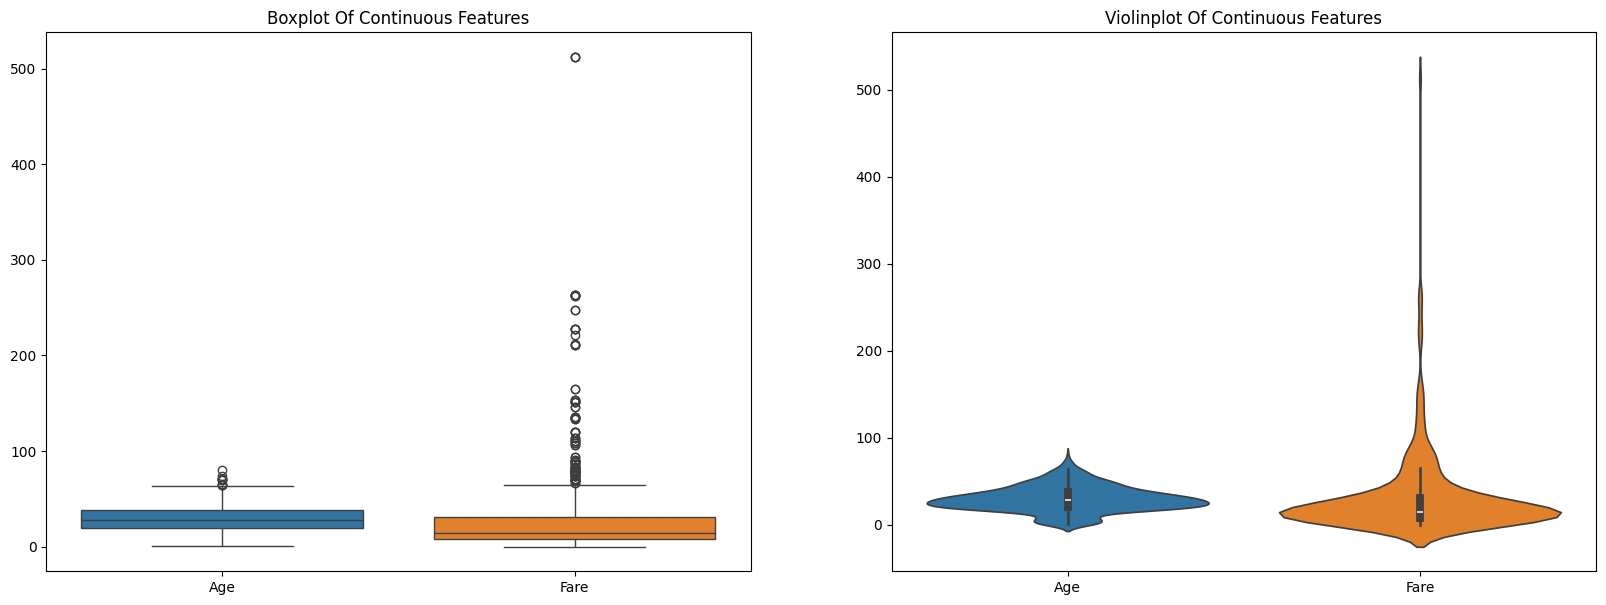

In [ ]:
# Explore the distribution of continuous features.
# - The box plot highlights potential outliers.
# - The violin plot reveals the distribution and density of the data.

fig, axes = plt.subplots(1,2, figsize=(20,7))
sns.boxplot(continuous_features, ax=axes[0])
axes[0].set_title("Boxplot Of Continuous Features")

sns.violinplot(continuous_features, ax=axes[1])
axes[1].set_title("Violinplot Of Continuous Features")

plt.show()

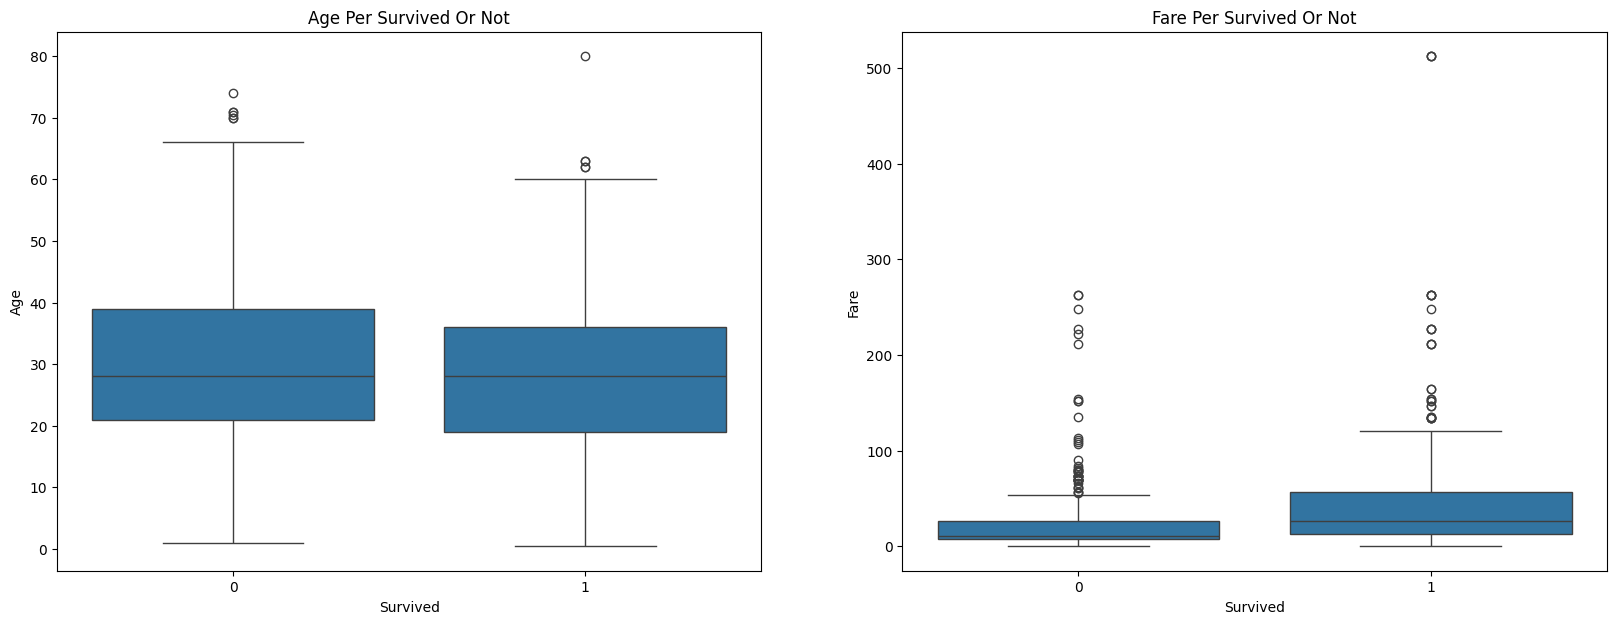

In [ ]:
# Compare the distributions of Age and Fare
# between passengers who survived and those who did not.

fig, axes = plt.subplots(1,2, figsize=(20,7))
sns.boxplot(x=data["Survived"], y=continuous_features["Age"], ax=axes[0])
axes[0].set_title("Age Per Survived Or Not")

sns.boxplot(x=data["Survived"], y=continuous_features["Fare"], ax=axes[1])
axes[1].set_title("Fare Per Survived Or Not")

plt.show()

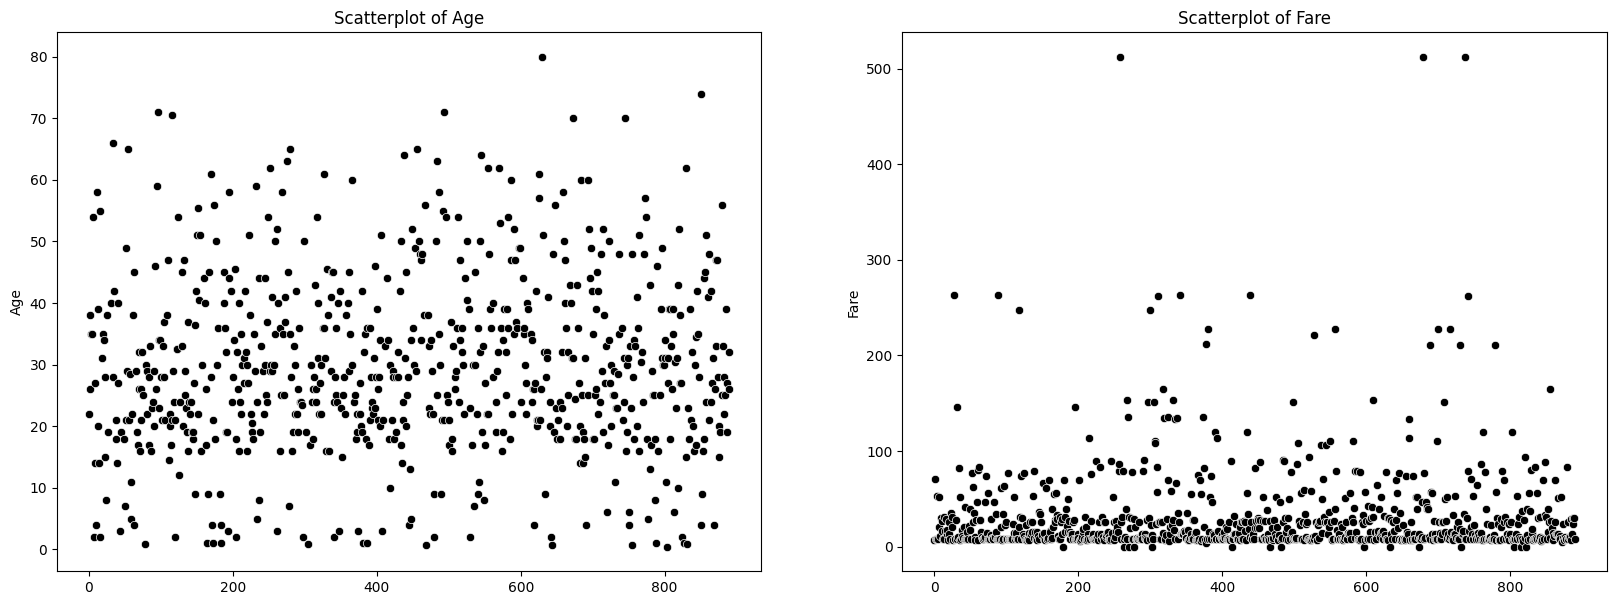

In [ ]:
# Visualize individual observations for the continuous features.
# Scatter plots make it easier to identify potential outliers
# and observe how values are distributed across the dataset.

fig, axes = plt.subplots(1,2, figsize=(20,7))
sns.scatterplot(data["Age"], ax=axes[0], color="black")
axes[0].set_title("Scatterplot of Age")

sns.scatterplot(data["Fare"], ax=axes[1], color="black")
axes[1].set_title("Scatterplot of Fare")

plt.show()

## Outliars Detector

In [43]:
def detect_IQR_outliars(input_data, columns):

    data_copy = input_data.copy()[columns]

    Q1 = np.percentile(data_copy, 25, axis=0)
    Q3 = np.percentile(data_copy, 75, axis=0)

    IQR = Q3 - Q1

    lower = Q1 - (1.5 * IQR)
    upper = Q3 + (1.5 * IQR)

    detected_outliars = set(np.where((data_copy > upper) | (data_copy < lower))[0])

    return detected_outliars

In [44]:
detected_outliars_idx = np.array(list(detect_IQR_outliars(input_data=data, columns=["Age", "Fare"])))

In [46]:
# Detect potential outliers using the Interquartile Range (IQR) method.
# The IQR rule flags observations that fall outside 1.5 × IQR from the
# first and third quartiles.
#
# After reviewing the detected observations, they appear to represent
# valid passenger ages and ticket fares rather than data entry errors.
# Therefore, these records are retained for the analysis.

print(f"{len(detected_outliars_idx)} samples identified as potential outliers.")
data.loc[detected_outliars_idx][["Sex","Age","Pclass","Fare"]]

116 samples identified as potential outliers.


,Sex,Age,Pclass,Fare
1,female,38.0,1,71.2833
520,female,30.0,1,93.5000
527,male,NaN,1,221.7792
537,female,30.0,1,106.4250
27,male,19.0,1,263.0000
...,...,...,...,...
486,female,35.0,1,90.0000
496,female,54.0,1,78.2667
498,female,25.0,1,151.5500
504,female,16.0,1,86.5000


In [48]:
# Fill the 2 missing values with the most frequent port
data["Embarked"] = data["Embarked"].fillna("S")

# Overall survival rate per port
embarked_survival = data.groupby("Embarked")["Survived"].agg(["mean", "count"])
embarked_survival.columns = ["Survival Rate", "Count"]
print(embarked_survival.round(3))

          Survival Rate  Count
Embarked                      
C                 0.554    168
Q                 0.390     77
S                 0.339    646


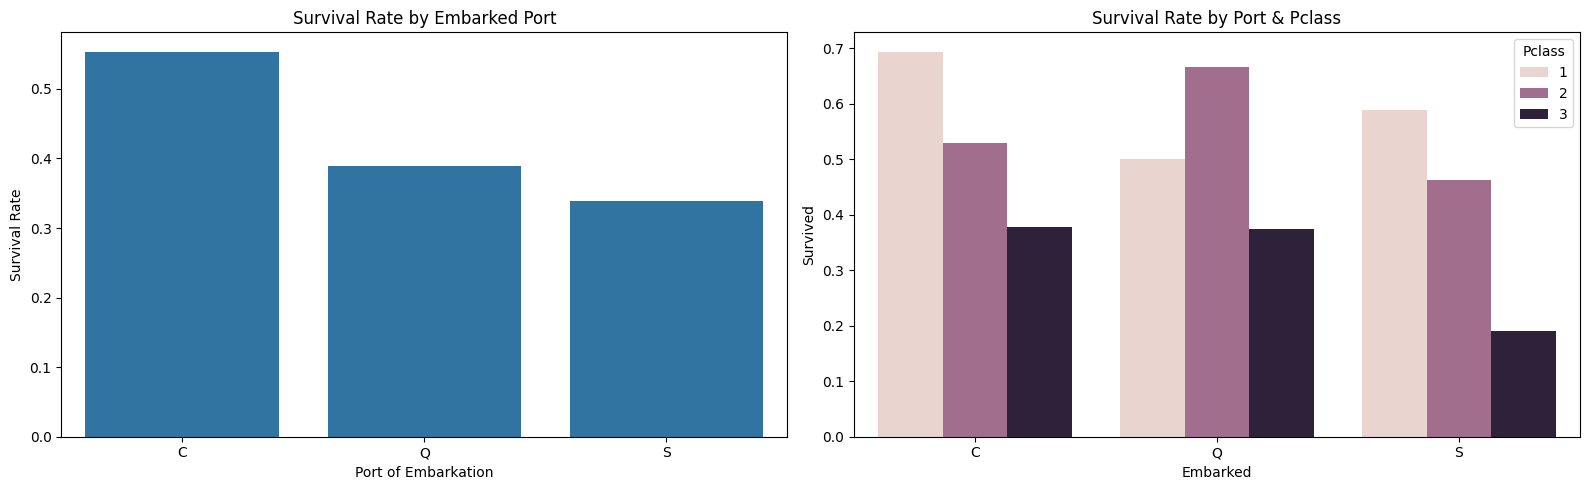

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Overall survival rate per port
embarked_sr = data.groupby("Embarked")["Survived"].mean()
sns.barplot(x=embarked_sr.index, y=embarked_sr.values, ax=axes[0])
axes[0].set_title("Survival Rate by Embarked Port")
axes[0].set_xlabel("Port of Embarkation")
axes[0].set_ylabel("Survival Rate")

# Right: Breakdown by Pclass — reveals WHY Cherbourg is higher
embarked_pclass = data.groupby(["Embarked", "Pclass"])["Survived"].mean().reset_index()
sns.barplot(data=embarked_pclass, x="Embarked", y="Survived", hue="Pclass", ax=axes[1])
axes[1].set_title("Survival Rate by Port & Pclass")

plt.tight_layout()
plt.show()

# Insights:
# - Cherbourg's advantage is explained by its high proportion of 1st-class passengers.
# - Among 3rd-class passengers, Southampton has the lowest survival rate (~19%).
# - The 2 missing values are safely filled with 'S' (most frequent, 72% of passengers).

## EDA Conclusion

The exploratory analysis reveals that survival on the Titanic was far from random — it was largely shaped by **social privilege, gender, and evacuation priority**.

### Key Findings

| Factor | Key Insight |
|---|---|
| **Sex** | Females survived at ~74% vs. ~19% for males — the single strongest raw predictor |
| **Pclass** | 1st class: 63% · 2nd class: 47% · 3rd class: 24% — wealth determined lifeboat access |
| **Fare** | Positively correlated with survival (r = 0.26), closely intertwined with Pclass |
| **Embarked** | Cherbourg: 55% · Queenstown: 39% · Southampton: 34% — driven by class composition per port |
| **Family Size** | Solo travelers had lower survival; small families (1–3 members) had the best odds |
| **Age** | Weak correlation overall, but younger passengers showed a slight survival advantage |

### What Drove Survival?

Three forces shaped who lived and who didn't:

**1. The "women and children first" policy** — Gender is the strongest single predictor. Female passengers were prioritized for lifeboats regardless of class, resulting in a survival rate nearly four times higher than males.

**2. Social class and wealth** — Pclass and Fare both point to the same reality: wealthier passengers survived at far higher rates. This is further reinforced by the Embarked analysis — Cherbourg's higher survival rate (55%) is not a port effect, but a class effect: it boarded the highest proportion of 1st-class passengers. Conversely, 3rd-class passengers from Southampton — the largest and poorest group — had only a 19% survival rate, the lowest of any subgroup in the dataset.

**3. Family dynamics** — Traveling alone was associated with lower survival, while passengers with one or two family members aboard showed better outcomes. However, groups with very high Parch or SibSp values had unreliable estimates due to small sample sizes.